# Lab 2

**Name:** K Hiroshini  
**Roll No:** CH.SC.U4AIE24026

## 2. Implementation Task

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

print("XOR Dataset:")
print("X =", X.numpy())
print("y =", y.numpy().flatten())

XOR Dataset:
X = [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y = [0. 1. 1. 0.]


In [2]:
class MLP(nn.Module):
    def __init__(self, hidden_units=4, activation='relu'):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(2, hidden_units)
        self.fc2 = nn.Linear(hidden_units, 1)
        if activation == 'relu':
            self.act = nn.ReLU()
        else:
            self.act = nn.Sigmoid()
        self.output = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.output(self.fc2(x))
        return x

In [3]:
def train_mlp(model, X, y, lr=0.01, epochs=100):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return loss_history

## 3. Hyperparameter Experimentation Log

In [4]:
results = []
all_losses = {}
exp_num = 1

for activation in ['sigmoid', 'relu']:
    for lr in [0.01, 0.1]:
        torch.manual_seed(42)
        model = MLP(hidden_units=4, activation=activation)
        losses = train_mlp(model, X, y, lr=lr, epochs=100)
        with torch.no_grad():
            preds = model(X)
            pred_labels = (preds >= 0.5).float()
            accuracy = (pred_labels == y).float().mean().item() * 100
        results.append({
            'Exp #': exp_num,
            'Activation': activation.capitalize(),
            'Learning Rate': lr,
            'Final Loss': round(losses[-1], 4),
            'Final Acc.': f"{accuracy:.2f}%"
        })
        all_losses[f"{activation}_lr{lr}"] = losses
        exp_num += 1

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Exp # Activation  Learning Rate  Final Loss Final Acc.
     1    Sigmoid           0.01      0.7172     50.00%
     2    Sigmoid           0.10      0.6926     50.00%
     3       Relu           0.01      0.7226     50.00%
     4       Relu           0.10      0.6831     50.00%


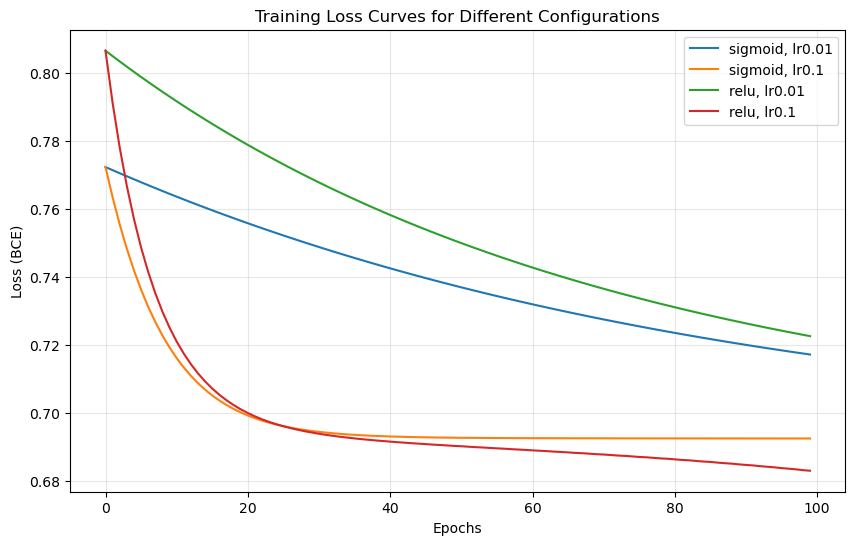

In [5]:
plt.figure(figsize=(10, 6))
for key, losses in all_losses.items():
    plt.plot(losses, label=key.replace('_', ', '))
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.title('Training Loss Curves for Different Configurations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()